# Cell 1: Environment & BLEU Setup

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time
import numpy as np
import matplotlib.pyplot as plt
import os
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

SEED = 7
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"[SUCCESS] CUDA is connected locally on: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("[WARNING] CUDA is not available. Running execution on CPU.")


[SUCCESS] CUDA is connected locally on: NVIDIA GeForce RTX 4060 Laptop GPU


# Cell 2: Dataset Loading & Tokenization (Word-Level)

In [2]:
# Special tokens mapping
PAD_TOKEN = 0
SOS_TOKEN = 1
EOS_TOKEN = 2
UNK_TOKEN = 3

def load_and_preprocess_data(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.read().strip().split('\n')

    eng_sentences = []
    fra_sentences = []
    for line in lines:
        parts = line.split('\t')
        if len(parts) >= 2:
            eng_sentences.append(parts[0].strip().lower())
            fra_sentences.append(parts[1].strip().lower())

    return eng_sentences, fra_sentences

def build_vocab(sentences):
    vocab = {"<PAD>": PAD_TOKEN, "<SOS>": SOS_TOKEN, "<EOS>": EOS_TOKEN, "<UNK>": UNK_TOKEN}
    idx2word = {PAD_TOKEN: "<PAD>", SOS_TOKEN: "<SOS>", EOS_TOKEN: "<EOS>", UNK_TOKEN: "<UNK>"}
    word_counts = {}

    for sentence in sentences:
        for word in sentence.split():
            word_counts[word] = word_counts.get(word, 0) + 1

    for word, _ in sorted(word_counts.items(), key=lambda x: x[1], reverse=True):
        if word not in vocab:
            idx = len(vocab)
            vocab[word] = idx
            idx2word[idx] = word

    return vocab, idx2word

# Try Eric's local path first, then a couple of common fallback locations, then prompt
# for an upload if running in Colab -- that covers both local runs and TA grading.
CANDIDATE_PATHS = [
    r"C:\Users\ericv\Downloads\vast_english_french.txt",
    "vast_english_french.txt",
    "/content/vast_english_french.txt",
]

data_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

if data_path is None:
    try:
        import google.colab
        from google.colab import files
        print("[INFO] Dataset not found in any known location -- running in Colab, please upload vast_english_french.txt")
        uploaded = files.upload()
        data_path = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "Could not find vast_english_french.txt. Checked: " + ", ".join(CANDIDATE_PATHS) +
            ". Place the file at one of these paths, or add its location to CANDIDATE_PATHS above."
        )

print(f"[INFO] Using dataset at: {data_path}")
eng_texts, fra_texts = load_and_preprocess_data(data_path)

print(f"Total sentence pairs loaded: {len(eng_texts)}")

# 80/20 Train/Validation Split
split_idx = int(len(eng_texts) * 0.8)
train_eng, val_eng = eng_texts[:split_idx], eng_texts[split_idx:]
train_fra, val_fra = fra_texts[:split_idx], fra_texts[split_idx:]

# Build vocabularies strictly from the training set to prevent data leakage
eng_vocab, eng_idx2word = build_vocab(train_eng)
fra_vocab, fra_idx2word = build_vocab(train_fra)

print(f"English Vocab Size: {len(eng_vocab)}")
print(f"French Vocab Size: {len(fra_vocab)}")


[INFO] Using dataset at: C:\Users\ericv\Downloads\vast_english_french.txt
Total sentence pairs loaded: 555
English Vocab Size: 853
French Vocab Size: 943


# Cell 3: Sequence Dataset & Token Padding

In [3]:
MAX_SEQ_LEN = 30 # A reasonable max length for this dataset

class TranslationDataset(Dataset):
    def __init__(self, src_texts, trg_texts, src_vocab, trg_vocab, max_len=MAX_SEQ_LEN):
        self.src_texts = src_texts
        self.trg_texts = trg_texts
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.src_texts)

    def text_to_indices(self, text, vocab):
        tokens = text.split()
        tokens = tokens[:self.max_len - 2] # Leave room for SOS and EOS
        indices = [vocab.get(token, UNK_TOKEN) for token in tokens]
        return [SOS_TOKEN] + indices + [EOS_TOKEN]

    def __getitem__(self, idx):
        src = self.text_to_indices(self.src_texts[idx], self.src_vocab)
        trg = self.text_to_indices(self.trg_texts[idx], self.trg_vocab)

        # Pad sequences to exactly max_len
        src_padded = src + [PAD_TOKEN] * (self.max_len - len(src))
        trg_padded = trg + [PAD_TOKEN] * (self.max_len - len(trg))

        return torch.tensor(src_padded, dtype=torch.long), torch.tensor(trg_padded, dtype=torch.long)


# Cell 4: The Seq2Seq Encoder-Decoder Transformer

In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=5000):
        super().__init__()
        pos = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2) * -(np.log(10000.0) / embed_dim))
        pe = torch.zeros(max_len, embed_dim)
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size, embed_dim, num_heads, num_layers, dropout=0.1, max_len=MAX_SEQ_LEN):
        super().__init__()
        self.src_embedding = nn.Embedding(src_vocab_size, embed_dim, padding_idx=PAD_TOKEN)
        self.trg_embedding = nn.Embedding(trg_vocab_size, embed_dim, padding_idx=PAD_TOKEN)
        self.positional_encoding = PositionalEncoding(embed_dim, max_len=max_len)

        self.transformer = nn.Transformer(
            d_model=embed_dim,
            nhead=num_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(embed_dim, trg_vocab_size)
        self.embed_dim = embed_dim

    def generate_masks(self, src, trg):
        # Source padding mask (True where padding exists)
        src_padding_mask = (src == PAD_TOKEN)
        # Target padding mask
        trg_padding_mask = (trg == PAD_TOKEN)

        # Target sequence causal mask (prevents looking ahead)
        trg_seq_len = trg.shape[1]
        trg_causal_mask = self.transformer.generate_square_subsequent_mask(trg_seq_len, device=trg.device)

        return src_padding_mask, trg_padding_mask, trg_causal_mask

    def forward(self, src, trg):
        src_padding_mask, trg_padding_mask, trg_causal_mask = self.generate_masks(src, trg)

        # Scale embeddings by sqrt(embed_dim) as per standard Transformer paper
        src_emb = self.positional_encoding(self.src_embedding(src) * np.sqrt(self.embed_dim))
        trg_emb = self.positional_encoding(self.trg_embedding(trg) * np.sqrt(self.embed_dim))

        out = self.transformer(
            src=src_emb,
            tgt=trg_emb,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=trg_padding_mask,
            memory_key_padding_mask=src_padding_mask,
            tgt_mask=trg_causal_mask
        )
        return self.fc_out(out)


# Cell 5: MT Training Engine & BLEU Evaluator

In [5]:
def translate_sentence(model, src_tensor, max_len=MAX_SEQ_LEN):
    model.eval()
    with torch.no_grad():
        src_tensor = src_tensor.unsqueeze(0).to(device)

        # Start the target sequence with just the <SOS> token
        trg_indexes = [SOS_TOKEN]

        for i in range(max_len):
            trg_tensor = torch.tensor(trg_indexes).unsqueeze(0).to(device)

            # Predict the next token
            output = model(src_tensor, trg_tensor)
            pred_token = output.argmax(2)[:, -1].item()
            trg_indexes.append(pred_token)

            if pred_token == EOS_TOKEN:
                break

    return trg_indexes

def calculate_metrics(model, dataloader):
    model.eval()
    total_loss = 0
    correct_tokens = 0
    total_tokens = 0
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

    with torch.no_grad():
        for src, trg in dataloader:
            src, trg = src.to(device), trg.to(device)

            # The target input to the decoder should not include the last token (EOS)
            # The target label for the loss should not include the first token (SOS)
            trg_input = trg[:, :-1]
            trg_expect = trg[:, 1:]

            output = model(src, trg_input)

            output_dim = output.shape[-1]
            output_flat = output.contiguous().view(-1, output_dim)
            trg_expect_flat = trg_expect.contiguous().view(-1)

            loss = criterion(output_flat, trg_expect_flat)
            total_loss += loss.item() * src.size(0)

            # Teacher-forced token accuracy (excluding padding) -- a training-signal
            # metric, NOT the "Traditional Sequence Accuracy" the report needs.
            # See evaluate_full_validation() below for that one.
            predictions = output.argmax(dim=-1)
            mask = trg_expect != PAD_TOKEN
            correct_tokens += ((predictions == trg_expect) & mask).sum().item()
            total_tokens += mask.sum().item()

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = correct_tokens / total_tokens if total_tokens > 0 else 0
    return avg_loss, accuracy

def train_mt_model(model, train_loader, val_loader, epochs=5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for src, trg in train_loader:
            src, trg = src.to(device), trg.to(device)

            trg_input = trg[:, :-1]
            trg_expect = trg[:, 1:]

            optimizer.zero_grad()
            output = model(src, trg_input)

            output_dim = output.shape[-1]
            output_flat = output.contiguous().view(-1, output_dim)
            trg_expect_flat = trg_expect.contiguous().view(-1)

            loss = criterion(output_flat, trg_expect_flat)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item() * src.size(0)

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        avg_val_loss, val_acc = calculate_metrics(model, val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

    return train_losses, val_losses, val_accuracies  # full per-epoch history, not just the last value

def evaluate_full_validation(model, src_texts, trg_texts, val_dataset, trg_idx2word, max_len=MAX_SEQ_LEN):
    """Real autoregressive decoding over the WHOLE validation set: exact-match sequence
    accuracy + corpus BLEU-4. This is what the rubric's "Traditional Sequence Accuracy"
    and "Validation BLEU-4" actually refer to -- calculate_metrics() above is teacher-forced
    and only meant as a training-time signal."""
    model.eval()
    exact_matches = 0
    references, hypotheses = [], []
    smoothing_fn = SmoothingFunction().method1

    for idx in range(len(src_texts)):
        src_tensor, _ = val_dataset[idx]
        pred_indices = translate_sentence(model, src_tensor, max_len=max_len)

        pred_words = []
        for tok in pred_indices[1:]:
            if tok == EOS_TOKEN:
                break
            pred_words.append(trg_idx2word.get(tok, "<UNK>"))
        pred_sentence = " ".join(pred_words)

        if pred_sentence == trg_texts[idx]:
            exact_matches += 1

        references.append([trg_texts[idx].split()])
        hypotheses.append(pred_words if pred_words else ["<EMPTY>"])

    seq_accuracy = exact_matches / len(src_texts) * 100
    bleu4 = corpus_bleu(references, hypotheses, smoothing_function=smoothing_fn)
    return seq_accuracy, bleu4


# Cell 6: DataLoaders

In [6]:
BATCH_SIZE = 64

train_dataset = TranslationDataset(train_eng, train_fra, eng_vocab, fra_vocab)
val_dataset = TranslationDataset(val_eng, val_fra, eng_vocab, fra_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


# Overfitting Diagnostic (Checking EPOCHS=50 Against the Full Curve)
The dataset here is tiny (~444 training sentences -> ~7 batches/epoch), so running many epochs
costs almost nothing. Before committing to EPOCHS=50 for the full 6-combination sweep below,
we run one representative config (2 blocks, 2 heads) for 200 epochs to see where validation
loss actually bottoms out, with a marker at epoch 50 to check whether it lines up.

c:\Users\ericv\anaconda3\envs\cifar_env\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
c:\Users\ericv\anaconda3\envs\cifar_env\Lib\site-packages\torch\nn\modules\transformer.py:502: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\NestedTensorImpl.cpp:180.)
  output = torch._nested_tensor_from_mask(


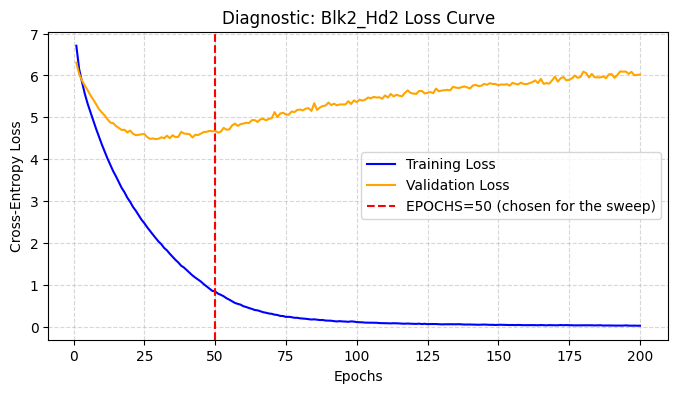

Best validation loss at epoch 29 of 200 (val loss 4.4788)
Validation loss at epoch 50: 4.6801
Val loss bottomed out before epoch 50 and may be rising again by then -- consider lowering EPOCHS or noting this in the report as an overfitting tradeoff.


In [7]:
torch.manual_seed(SEED)
diag_model = Seq2SeqTransformer(
    src_vocab_size=len(eng_vocab), trg_vocab_size=len(fra_vocab),
    embed_dim=64, num_heads=2, num_layers=2
).to(device)

diag_epochs = 200
diag_train_hist, diag_val_hist, _ = train_mt_model(diag_model, train_loader, val_loader, epochs=diag_epochs)

plt.figure(figsize=(8, 4))
plt.plot(range(1, diag_epochs + 1), diag_train_hist, label='Training Loss', color='blue')
plt.plot(range(1, diag_epochs + 1), diag_val_hist, label='Validation Loss', color='orange')
plt.axvline(x=50, color='red', linestyle='--', label='EPOCHS=50 (chosen for the sweep)')
plt.title('Diagnostic: Blk2_Hd2 Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

best_epoch = int(np.argmin(diag_val_hist)) + 1
print(f"Best validation loss at epoch {best_epoch} of {diag_epochs} (val loss {diag_val_hist[best_epoch-1]:.4f})")
print(f"Validation loss at epoch 50: {diag_val_hist[49]:.4f}")
if best_epoch < 50:
    print("Val loss bottomed out before epoch 50 and may be rising again by then -- "
          "consider lowering EPOCHS or noting this in the report as an overfitting tradeoff.")
elif best_epoch > 50:
    print("Val loss was still improving at epoch 50 -- the model may benefit from more epochs than 50.")
else:
    print("Epoch 50 lines up well with the best validation loss observed.")


# Cell 7: The 6-Combination Sweep & Qualitative Output

[INFO] Starting Problem 3 Translation Sweep...
-> Training Blk:1_Hd:2...


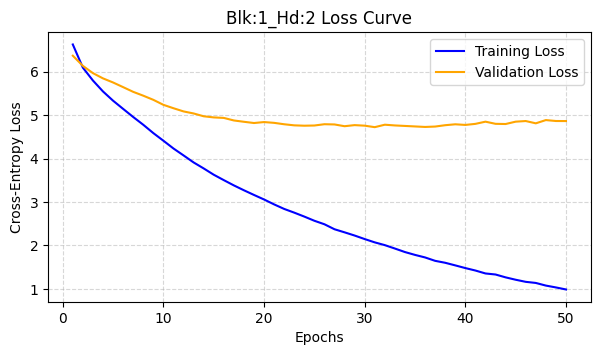

-> Training Blk:1_Hd:4...


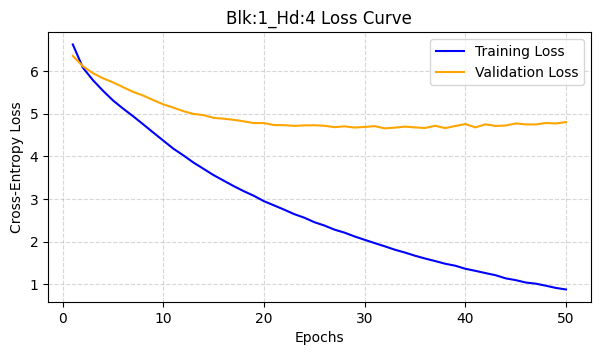

-> Training Blk:2_Hd:2...


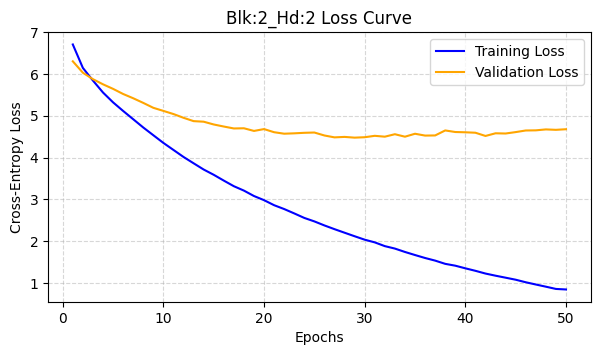

-> Training Blk:2_Hd:4...


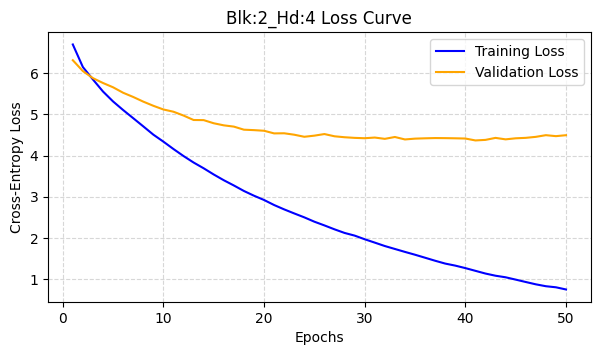

-> Training Blk:4_Hd:2...


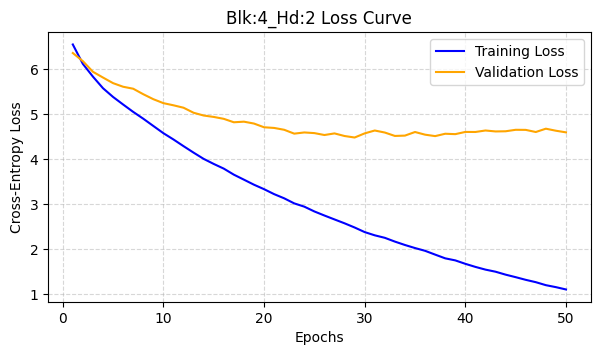

-> Training Blk:4_Hd:4...


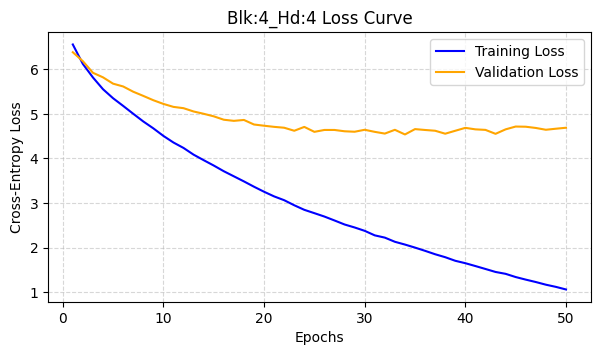


Architecture    | Train Loss  | Val Loss  | Seq Acc %  | BLEU-4 
Blk:1_Hd:2      | 0.9869      | 4.8625    | 0.0        | 0.1375 
Blk:1_Hd:4      | 0.8762      | 4.8009    | 0.0        | 0.1412 
Blk:2_Hd:2      | 0.8445      | 4.6801    | 0.9        | 0.1653 
Blk:2_Hd:4      | 0.7548      | 4.4957    | 0.0        | 0.1591 
Blk:4_Hd:2      | 1.0989      | 4.5957    | 0.0        | 0.1279 
Blk:4_Hd:4      | 1.0603      | 4.6895    | 0.0        | 0.1356 


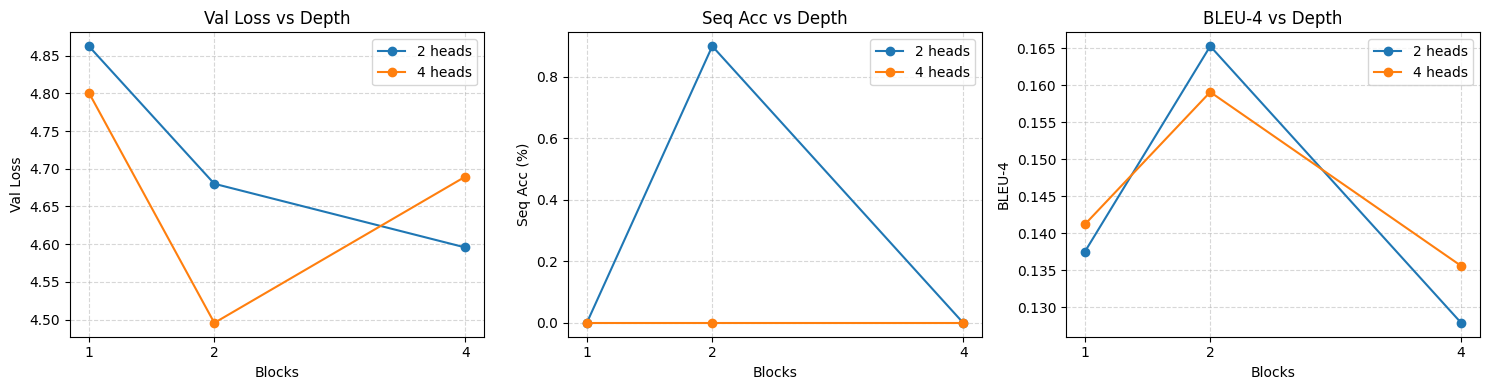


### QUALITATIVE TRANSLATION EXAMPLES (Validation Set) ###

English:    she practices the cello for three hours every day
Reference:  elle pratique le violoncelle pendant trois heures chaque jour
Generated:  elle court dans le parc
Exact Match: False | BLEU-4: 0.0287

English:    the luxury hotel is incredibly clean and comfortable
Reference:  l'hôtel de luxe est incroyablement propre et confortable
Generated:  les feuilles d'automne dans le parc
Exact Match: False | BLEU-4: 0.0000

English:    i look forward to the upcoming summer holidays
Reference:  j'attends avec impatience les prochaines vacances d'été
Generated:  j'ai hâte de collaborer avec votre équipe
Exact Match: False | BLEU-4: 0.0330


In [8]:
EPOCHS = 50
EMBED_DIM = 64

architectures = [(1, 2), (1, 4), (2, 2), (2, 4), (4, 2), (4, 4)]
mt_results = {}
best_model = None
best_val_loss = float('inf')

print("[INFO] Starting Problem 3 Translation Sweep...")

for blocks, heads in architectures:
    config_name = f"Blk:{blocks}_Hd:{heads}"
    print(f"-> Training {config_name}...")

    torch.manual_seed(SEED)
    model = Seq2SeqTransformer(
        src_vocab_size=len(eng_vocab),
        trg_vocab_size=len(fra_vocab),
        embed_dim=EMBED_DIM,
        num_heads=heads,
        num_layers=blocks
    ).to(device)

    t_hist, v_hist, _ = train_mt_model(model, train_loader, val_loader, epochs=EPOCHS)
    seq_acc, bleu4 = evaluate_full_validation(model, val_eng, val_fra, val_dataset, fra_idx2word)

    if v_hist[-1] < best_val_loss:
        best_val_loss = v_hist[-1]
        best_model = model

    mt_results[config_name] = {
        "Train Loss": round(t_hist[-1], 4),
        "Val Loss": round(v_hist[-1], 4),
        "Seq Acc %": round(seq_acc, 2),
        "BLEU-4": round(bleu4, 4)
    }

    plt.figure(figsize=(7, 3.5))
    plt.plot(range(1, EPOCHS + 1), t_hist, label='Training Loss', color='blue')
    plt.plot(range(1, EPOCHS + 1), v_hist, label='Validation Loss', color='orange')
    plt.title(f'{config_name} Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Cross-Entropy Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

print("\n" + "="*80)
print(f"{'Architecture':<15} | {'Train Loss':<11} | {'Val Loss':<9} | {'Seq Acc %':<10} | {'BLEU-4':<7}")
print("="*80)
for config, data in mt_results.items():
    print(f"{config:<15} | {data['Train Loss']:<11} | {data['Val Loss']:<9} | {data['Seq Acc %']:<10} | {data['BLEU-4']:<7}")
print("="*80)

# Comparison chart across the sweep
config_map = {"Blk:1_Hd:2": (1, 2), "Blk:1_Hd:4": (1, 4), "Blk:2_Hd:2": (2, 2),
              "Blk:2_Hd:4": (2, 4), "Blk:4_Hd:2": (4, 2), "Blk:4_Hd:4": (4, 4)}
blocks_list = [1, 2, 4]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for heads in [2, 4]:
    vloss = [mt_results[p]["Val Loss"] for p, (b, h) in config_map.items() if h == heads]
    sacc = [mt_results[p]["Seq Acc %"] for p, (b, h) in config_map.items() if h == heads]
    bleu = [mt_results[p]["BLEU-4"] for p, (b, h) in config_map.items() if h == heads]
    axes[0].plot(blocks_list, vloss, marker='o', label=f'{heads} heads')
    axes[1].plot(blocks_list, sacc, marker='o', label=f'{heads} heads')
    axes[2].plot(blocks_list, bleu, marker='o', label=f'{heads} heads')
for ax, title, ylab in zip(axes, ['Val Loss vs Depth', 'Seq Acc vs Depth', 'BLEU-4 vs Depth'],
                           ['Val Loss', 'Seq Acc (%)', 'BLEU-4']):
    ax.set_xlabel('Blocks'); ax.set_ylabel(ylab); ax.set_title(title); ax.legend()
    ax.set_xticks(blocks_list); ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- QUALITATIVE VALIDATION (Using Best Model) ---
print("\n### QUALITATIVE TRANSLATION EXAMPLES (Validation Set) ###")
smoothing_fn = SmoothingFunction().method1
test_indices = [0, 5, 10] # A few sentences from the validation split

for idx in test_indices:
    src_text = val_eng[idx]
    trg_text = val_fra[idx]

    # Grab the pre-processed tensor representation from the dataset
    src_tensor, _ = val_dataset[idx]

    # Run through auto-regressive translation generator
    pred_indices = translate_sentence(best_model, src_tensor)

    # Convert indices back to words (stop at EOS)
    pred_words = []
    for i in pred_indices[1:]: # Skip SOS
        if i == EOS_TOKEN:
            break
        pred_words.append(fra_idx2word.get(i, "<UNK>"))

    pred_sentence = " ".join(pred_words)
    target_words = trg_text.split()

    exact_match = (pred_sentence == trg_text)
    bleu_score = sentence_bleu([target_words], pred_words, smoothing_function=smoothing_fn)

    print(f"\nEnglish:    {src_text}")
    print(f"Reference:  {trg_text}")
    print(f"Generated:  {pred_sentence}")
    print(f"Exact Match: {exact_match} | BLEU-4: {bleu_score:.4f}")
